In [1]:
# === CELL 1: Imports y dependencias ===
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym
from gymnasium import spaces

try:
    from stable_baselines3 import PPO
    from stable_baselines3.common.vec_env import DummyVecEnv
except ImportError:
    print("Instala stable-baselines3 antes de ejecutar este notebook.")

# Breakpoint detection basado en RL quasi-supervisado

- **setup**: tomas dos vectores de entrada: el ndvi y un vector categorico que le indica al algoritmo el landcover (0: bosque, 1: no-bosque)
- **idea**: la idea es que el sistema tenga dos estados, y aprende a seguir la serie de tiempo caracteristica de cada uno de ellos.
- **como se usa**: si entrena, se puede cambiar el input de 0 a 1 a ver a que modelo ajusta mejor

### Levanto series de NDVI

In [2]:
filename = 'sitio1_deforestacion_train.csv'
dataFolder = 'SERIES_NUEVAS/'
df = pd.read_csv(dataFolder+filename)

In [3]:
df.columns.values

array(['Unnamed: 0', 'lon', 'lat', 'sitio', 'anio', 'mes', 'nubes',
       '2000-02-18', '2000-03-05', '2000-03-21', '2000-04-06',
       '2000-04-22', '2000-05-08', '2000-05-24', '2000-06-09',
       '2000-06-25', '2000-07-11', '2000-07-27', '2000-08-12',
       '2000-08-28', '2000-09-13', '2000-09-29', '2000-10-15',
       '2000-10-31', '2000-11-16', '2000-12-02', '2000-12-18',
       '2001-01-01', '2001-01-17', '2001-02-02', '2001-02-18',
       '2001-03-06', '2001-03-22', '2001-04-07', '2001-04-23',
       '2001-05-09', '2001-05-25', '2001-06-10', '2001-06-26',
       '2001-07-12', '2001-07-28', '2001-08-13', '2001-08-29',
       '2001-09-14', '2001-09-30', '2001-10-16', '2001-11-01',
       '2001-11-17', '2001-12-03', '2001-12-19', '2002-01-01',
       '2002-01-17', '2002-02-02', '2002-02-18', '2002-03-06',
       '2002-03-22', '2002-04-07', '2002-04-23', '2002-05-09',
       '2002-05-25', '2002-06-10', '2002-06-26', '2002-07-12',
       '2002-07-28', '2002-08-13', '2002-08-29', '

In [4]:
df.shape

(4610, 437)

Ploteo eventos de deforestacion para algunos pixeles

In [7]:
nSeries = 500

In [8]:
ndviDataStart = 7
testPixel = np.random.choice(df.shape[0], size=nSeries, replace=False)

In [9]:
testPixel

array([1882, 1141, 4554,  374,   86,  341, 1757, 3865, 2777, 2800,  896,
       2642, 1879, 1111, 1276, 4472, 2099, 2886, 4504, 1304, 3640, 4016,
       1131,  834, 2704, 1151, 2780, 1983,  430, 3092, 2063, 3124, 1108,
       3413, 3003, 1050, 1204, 1755, 2591, 1534,  408, 1078, 2964, 2136,
       1064, 3449, 2272, 1338, 2071, 3731,  286, 3930,  389,  729, 2767,
       4585, 4544, 4157, 3840, 2348, 4560, 2336,  958, 2154, 4598, 3678,
        749, 4277, 1836, 3122,  309,  818, 2834, 2367, 2766, 3227, 3400,
        898, 4270, 4048, 3260, 2474, 1059,  302, 3601, 4450, 2716,  419,
        727, 3829, 2357, 2453, 1889, 1234, 1170, 1163, 2289, 3233, 3769,
       3136, 1114, 3391,  614, 4272, 3441, 4386,  697, 2582, 2563,  495,
       2373, 3366, 1827, 2528,  553, 1125, 1786,    9,  461, 2494, 4260,
       3658, 1903, 4313, 2719, 3795, 4525, 1086, 1481, 3375, 3913,  950,
       4564, 3280, 1973, 1573,  397,  681,  604, 4380, 4419,  413, 2493,
        441, 1741, 3131, 1020, 3204,  411, 4296,  5

### reconstruyo vector fechas

In [10]:
fechas = pd.to_datetime(df.columns[ndviDataStart:])

### Incluyo fecha deforestacion

In [11]:
df['fechaDef'] = pd.to_datetime({
    'year': df['anio'].astype(int),
    'month': df['mes'].astype(int),
    'day': 1
})

#### reordeno columna

In [12]:
col = df.pop('fechaDef')
df.insert(1, 'fechaDef', col)

In [13]:
df.drop(columns=['Unnamed: 0'], inplace=True)

In [14]:
df

,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,2000-03-21,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,0.4052,0.366167,0.327133,...,0.2710,0.1923,0.2186,0.1878,0.1518,0.1496,0.1639,0.15950,0.1634,0.3735
1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,0.4098,0.371700,0.333600,...,0.2710,0.1935,0.2186,0.1777,0.1468,0.1597,0.1745,0.18590,0.1543,0.3981
2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,0.4156,0.376000,0.336400,...,0.2879,0.2050,0.2131,0.1896,0.1546,0.1597,0.1620,0.15510,0.1543,0.3981
3,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,0.4236,0.387333,0.351067,...,0.2938,0.1944,0.2257,0.1864,0.1557,0.1622,0.1518,0.14760,0.1630,0.4007
4,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,0.4252,0.388200,0.351200,...,0.2822,0.1773,0.2205,0.1724,0.1429,0.1555,0.1588,0.14520,0.1795,0.3924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,0.3661,0.366100,0.366100,...,0.2491,0.2040,0.2330,0.1758,0.1567,0.1599,0.1482,0.16100,0.1483,0.3382
4606,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,0.3370,0.337000,0.337000,...,0.2811,0.2147,0.2321,0.1984,0.1659,0.1639,0.1564,0.17860,0.1653,0.3339
4607,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,0.4503,0.370950,0.291600,...,0.2830,0.2061,0.2355,0.1951,0.1620,0.1643,0.1542,0.15950,0.1648,0.3430
4608,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,0.4493,0.376150,0.303000,...,0.2632,0.2074,0.2225,0.1851,0.1586,0.1520,0.1678,0.16405,0.1603,0.3377


In [15]:
ndviDataStart+=1

In [16]:
fechas.shape

(430,)

### Grafico datos

In [17]:
# for pixel in testPixel:

#     deforestationDate = df['fechaDef'].iloc[pixel]
#     ndvi = df.iloc[pixel, ndviDataStart-1:].values

    # plt.plot(fechas, ndvi)
    # plt.axvline(deforestationDate, color='red', linestyle='--', label='Deforestación')
    # plt.show()

### Normalizo NDVI

In [18]:
df.iloc[:, ndviDataStart-1:]

,2000-02-18,2000-03-05,2000-03-21,2000-04-06,2000-04-22,2000-05-08,2000-05-24,2000-06-09,2000-06-25,2000-07-11,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,0.4052,0.366167,0.327133,0.2881,0.2742,0.2650,0.2791,0.2103,0.18975,0.1692,...,0.2710,0.1923,0.2186,0.1878,0.1518,0.1496,0.1639,0.15950,0.1634,0.3735
1,0.4098,0.371700,0.333600,0.2955,0.2863,0.2774,0.2879,0.2178,0.19515,0.1725,...,0.2710,0.1935,0.2186,0.1777,0.1468,0.1597,0.1745,0.18590,0.1543,0.3981
2,0.4156,0.376000,0.336400,0.2968,0.2691,0.2774,0.2926,0.2178,0.19355,0.1693,...,0.2879,0.2050,0.2131,0.1896,0.1546,0.1597,0.1620,0.15510,0.1543,0.3981
3,0.4236,0.387333,0.351067,0.3148,0.2671,0.2768,0.2882,0.2238,0.21700,0.1708,...,0.2938,0.1944,0.2257,0.1864,0.1557,0.1622,0.1518,0.14760,0.1630,0.4007
4,0.4252,0.388200,0.351200,0.3142,0.2711,0.2760,0.2842,0.2104,0.21750,0.1748,...,0.2822,0.1773,0.2205,0.1724,0.1429,0.1555,0.1588,0.14520,0.1795,0.3924
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,0.3661,0.366100,0.366100,0.3454,0.3414,0.3109,0.3306,0.2610,0.26310,0.1811,...,0.2491,0.2040,0.2330,0.1758,0.1567,0.1599,0.1482,0.16100,0.1483,0.3382
4606,0.3370,0.337000,0.337000,0.3327,0.3261,0.2991,0.3306,0.2477,0.26440,0.1808,...,0.2811,0.2147,0.2321,0.1984,0.1659,0.1639,0.1564,0.17860,0.1653,0.3339
4607,0.4503,0.370950,0.291600,0.3369,0.3368,0.2968,0.3360,0.2563,0.27640,0.1771,...,0.2830,0.2061,0.2355,0.1951,0.1620,0.1643,0.1542,0.15950,0.1648,0.3430
4608,0.4493,0.376150,0.303000,0.3280,0.3223,0.3039,0.3255,0.2475,0.26120,0.1802,...,0.2632,0.2074,0.2225,0.1851,0.1586,0.1520,0.1678,0.16405,0.1603,0.3377


In [19]:
# === CELL 3: Preprocesamiento y split ===
# Normalización [-1,1]
ndvi = df.iloc[:, ndviDataStart-1:].values #df2.iloc[:,1:].values
minv, maxv = ndvi.min(), ndvi.max()
def normalize(x): return 2*(x - minv)/(maxv - minv) - 1
def denormalize(z): return ((z+1)/2*(maxv - minv)) + minv

# df['ndvi_norm'] = normalize(ndvi)
# ndvi_norm = df.iloc[:, ndviDataStart-1:].apply(normalize)
df.iloc[:, ndviDataStart-1:] = df.iloc[:, ndviDataStart-1:].apply(normalize)

In [20]:
# mask = (fechas.year == deforestationDate.year) & (fechas.month == deforestationDate.month)
# deforestationDate = np.where(mask)[0][0]
# train_df = ndvi_norm.iloc[:deforestationDate].reset_index(drop=True)
# test_df = ndvi_norm.iloc[deforestationDate:].reset_index(drop=True)
df

,fechaDef,lon,lat,sitio,anio,mes,nubes,2000-02-18,2000-03-05,2000-03-21,...,2018-05-25,2018-06-10,2018-06-26,2018-07-12,2018-07-28,2018-08-13,2018-08-29,2018-09-14,2018-09-30,2018-10-16
0,2012-06-01,-63.090370,-25.042652,1.0,2012.0,6.0,0.0,-0.136535,-0.223334,-0.310133,...,-0.434957,-0.609962,-0.551479,-0.619969,-0.700022,-0.704914,-0.673115,-0.682900,-0.674227,-0.207027
1,2012-06-01,-63.088070,-25.042652,1.0,2012.0,6.0,0.0,-0.126306,-0.211030,-0.295753,...,-0.434957,-0.607294,-0.551479,-0.642428,-0.711141,-0.682455,-0.649544,-0.624194,-0.694463,-0.152324
2,2012-06-01,-63.085771,-25.042652,1.0,2012.0,6.0,0.0,-0.113409,-0.201468,-0.289526,...,-0.397376,-0.581721,-0.563709,-0.615966,-0.693796,-0.682455,-0.677340,-0.692684,-0.694463,-0.152324
3,2012-06-01,-63.081172,-25.042652,1.0,2012.0,6.0,0.0,-0.095619,-0.176266,-0.256912,...,-0.384256,-0.605292,-0.535690,-0.623082,-0.691350,-0.676896,-0.700022,-0.709362,-0.675117,-0.146542
4,2012-06-01,-63.078872,-25.042652,1.0,2012.0,6.0,0.0,-0.092061,-0.174338,-0.256616,...,-0.410051,-0.643318,-0.547254,-0.654214,-0.719813,-0.691795,-0.684456,-0.714699,-0.638426,-0.164999
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4605,2013-08-01,-62.970028,-25.392651,1.0,2013.0,8.0,0.0,-0.223482,-0.223482,-0.223482,...,-0.483656,-0.583945,-0.519457,-0.646653,-0.689126,-0.682010,-0.708028,-0.679564,-0.707805,-0.285524
4606,2013-08-01,-62.968809,-25.394735,1.0,2013.0,8.0,0.0,-0.288192,-0.288192,-0.288192,...,-0.412497,-0.560151,-0.521459,-0.596398,-0.668668,-0.673115,-0.689793,-0.640427,-0.670002,-0.295086
4607,2013-08-01,-62.969896,-25.396818,1.0,2013.0,8.0,0.0,-0.036246,-0.212697,-0.389148,...,-0.408272,-0.579275,-0.513898,-0.603736,-0.677340,-0.672226,-0.694685,-0.682900,-0.671114,-0.274850
4608,2013-08-01,-62.968677,-25.398901,1.0,2013.0,8.0,0.0,-0.038470,-0.201134,-0.363798,...,-0.452302,-0.576384,-0.542806,-0.625973,-0.684901,-0.699577,-0.664443,-0.672782,-0.681121,-0.286636


#### Definicion conjuntos de train y test

In [21]:
print('Numero de series analizadas:', len(testPixel))

Numero de series analizadas: 500


In [22]:
nTrain = int(nSeries*0.8)

trainSeries = np.random.choice(testPixel, size=nTrain, replace=False)
testSeries = [int(i) for i in testPixel if i not in trainSeries]

In [23]:
trainSeries, testSeries

(array([ 430, 2556, 2462, 2685,  394,  751,  896,  183, 3233, 2424, 1836,
        4497, 3365, 1286, 3795,  313, 2174,  895, 4012, 4335,  749, 4380,
        1481, 3245, 3840, 1197,  817, 1414, 1029,  286, 2652, 1557, 1431,
        1775, 1245, 2591, 4525, 1616, 3546,  719, 1627, 1771, 2736,  361,
        2777, 1369, 2063, 3930, 4585, 1043, 3678, 1652, 2846, 2480, 3285,
        3227, 4467, 2531,  897,  200, 1028,  553, 1244, 3697, 2453,  985,
        3786, 2071,  388, 1960, 2716, 4226, 1114, 2821, 3577,  374, 1059,
        3911, 1453, 1209, 1527, 3950, 1111, 1759, 1276, 3956, 1725, 4487,
        4503, 4350, 4074,  248, 2964, 2927, 3611,  933, 2963, 2154, 4516,
         327, 3087, 4533,  341, 1331, 2044,  411, 3505,  186, 2719,  110,
        2397, 2766, 2714,  609, 1388, 3676, 4200, 1794, 1573, 2834, 2278,
         950, 2521, 4360, 4493,  898,  441, 2183, 2640, 3688, 1871, 1108,
         475,  681,  877, 3280, 2836,  130, 3585,  868,  838, 1201, 3235,
        2494, 2250, 2052, 2886, 3926, 

In [24]:
df.iloc[0,ndviDataStart-1:]

2000-02-18   -0.136535
2000-03-05   -0.223334
2000-03-21   -0.310133
2000-04-06   -0.396931
2000-04-22   -0.427841
                ...   
2018-08-13   -0.704914
2018-08-29   -0.673115
2018-09-14     -0.6829
2018-09-30   -0.674227
2018-10-16   -0.207027
Name: 0, Length: 430, dtype: object

In [25]:
train_list = []
test_list = []

for i in trainSeries:
    ndvi_list = df.iloc[i,ndviDataStart-1:].values
    input2 = fechas < df['fechaDef'].iloc[i] #### Sintetizo serie booleana para indicar que landcover hay
    input2 = [np.float64(1.0) if x == True else 0 for x in input2]
    train_list.append([ndvi_list, input2]) #pego las dos series

for i in testSeries:
    ndvi_list = df.iloc[i,ndviDataStart-1:].values
    input2 = fechas < df['fechaDef'].iloc[i] #### Sintetizo serie booleana para indicar que landcover hay
    input2 = [np.float64(1.0) if x == True else 0 for x in input2]
    test_list.append([ndvi_list, input2]) #pego las dos series

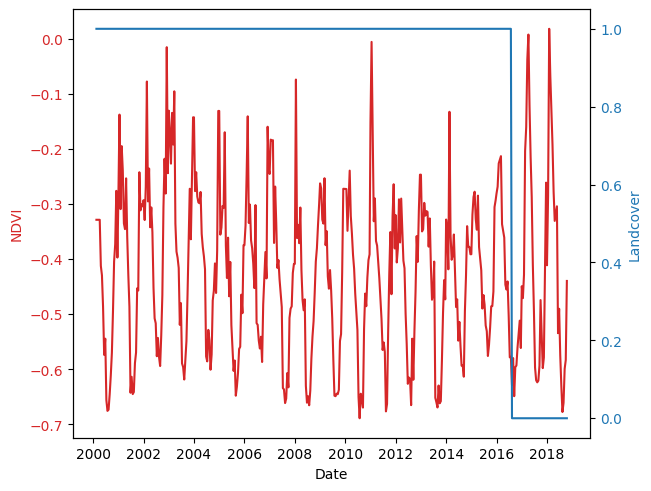

In [26]:
# plt.plot(fechas, train_list[0][0])
# plt.plot(fechas, train_list[0][1])

index = 4
fig, ax1 = plt.subplots(layout='constrained') # use constrained layout

color1 = 'tab:red'
ax1.set_xlabel('Date')
ax1.set_ylabel('NDVI', color=color1)
ax1.plot(fechas, train_list[index][0], color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

# 3. Create the Secondary Y-axis
ax2 = ax1.twinx()

# 4. Plot on the Secondary Y-axis
color2 = 'tab:blue'
ax2.set_ylabel('Landcover', color=color2)
ax2.plot(fechas, train_list[index][1], color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

### Definicion Entorno gym.Env para que tome stable_baselines3

In [27]:
class NDVIMultiEnv(gym.Env):
    def __init__(self, series_list, window=23):
        super().__init__()
        
        # Convertir explícitamente a float32
        self.series_list = [np.array(s, dtype=np.float32) for s in series_list]
        self.n_series = len(series_list)
        self.window = window
        self.length = min(len(s) for s in series_list)

        # Asegurarse que data sea float32
        self.data = np.stack([s[:self.length] for s in self.series_list], axis=1).astype(np.float32)

        self.observation_space = spaces.Box(
            low=-1.5, high=1.5, 
            shape=(self.window, self.n_series), 
            dtype=np.float32
        )
        self.action_space = spaces.Box(
            low=-1.5, high=1.5, 
            shape=(self.n_series,), 
            dtype=np.float32
        )

        self.current_step = self.window

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.window
        obs = self.data[self.current_step - self.window : self.current_step].astype(np.float32)
        return obs, {}

    def step(self, action):
        # Obtener el valor objetivo actual
        target = self.data[self.current_step]
        
        # Calcular recompensa como el error cuadrático medio negativo
        reward = -np.mean((action - target) ** 2)
        
        # Avanzar un paso
        self.current_step += 1
        
        # Verificar si el episodio ha terminado
        done = self.current_step >= self.length
        
        # Obtener la siguiente observación
        if not done:
            next_obs = self.data[self.current_step - self.window : self.current_step].astype(np.float32)
        else:
            next_obs = np.zeros_like(self.observation_space.sample(), dtype=np.float32)
        
        info = {}
        return next_obs, reward, done, False, info

In [28]:
# Wrapper que muestrea una serie por episodio para entrenar con todas las series
class MultiSeriesSamplerEnv(gym.Env):
    def __init__(self, series_pairs, window=23):
        super().__init__()
        import numpy as _np
        from gymnasium import spaces as _spaces
        self.series_pairs = series_pairs
        self.n_series = len(series_pairs)
        self.window = window
        # length basada en la longitud de la serie NDVI (primer elemento del par)
        self.length = min(len(s[0]) for s in series_pairs)
        # observation: ventana x 2 (NDVI, class)
        self.observation_space = _spaces.Box(low=-1.5, high=1.5, shape=(window, 2), dtype=_np.float32)
        self.action_space = _spaces.Box(low=-1.5, high=1.5, shape=(2,), dtype=_np.float32)

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        import numpy as _np
        # elegir una serie al azar para el episodio
        self.current_series = _np.random.randint(0, self.n_series)
        self.current_step = self.window
        ndvi = _np.array(self.series_pairs[self.current_series][0], dtype=_np.float32)[:self.length]
        cat  = _np.array(self.series_pairs[self.current_series][1], dtype=_np.float32)[:self.length]
        self.data = _np.stack([ndvi, cat], axis=1)  # shape (length, 2)
        obs = self.data[self.current_step - self.window : self.current_step]
        return obs, {}

    def step(self, action):
        import numpy as _np
        target = self.data[self.current_step]
        reward = -_np.mean((action - target) ** 2)
        self.current_step += 1
        done = self.current_step >= self.length
        if not done:
            next_obs = self.data[self.current_step - self.window : self.current_step]
        else:
            next_obs = _np.zeros((self.window, 2), dtype=_np.float32)
        info = {}
        return next_obs, reward, done, False, {}

# Crear env a usar para entrenar con todas las series
# env = NDVIMultiEnv(train_list, window=23)  # antiguo
# usar el wrapper:
env = MultiSeriesSamplerEnv(train_list, window=23)
obs, _ = env.reset()
print("Shape de observación (wrapper):", obs.shape)

Shape de observación (wrapper): (23, 2)


## Entrenamiento

In [29]:
# Crear entorno usando el wrapper que muestrea una serie por episodio (entrena con todas las series)
# env = NDVIMultiEnv(train_list[0], window=23) # entreno con una sola serie (antiguo)
# env = NDVIMultiEnv(train_list, window=23) # NO usar esto con train_list tal cual
env = MultiSeriesSamplerEnv(train_list, window=23)
obs, _ = env.reset()
print("Shape de observación (wrapper):", obs.shape)

# Smoke-test: dar algunos pasos con acciones aleatorias para verificar shapes y recompensas
import numpy as _np
actions = []
rewards = []
done = False
cnt = 0
while (not done) and cnt < 5:
    a = env.action_space.sample()
    next_obs, reward, done, _, _ = env.step(a)
    actions.append(a)
    rewards.append(reward)
    cnt += 1
print('Pasos realizados:', cnt)
print('Acción ejemplo:', actions[0] if len(actions)>0 else None)
print('Recompensa ejemplo:', rewards[0] if len(rewards)>0 else None)

Shape de observación (wrapper): (23, 2)
Pasos realizados: 5
Acción ejemplo: [0.91274756 1.1770847 ]
Recompensa ejemplo: -0.4936083


In [30]:
from stable_baselines3.common.vec_env import DummyVecEnv

# SB3 funciona bien con env vectorizado; envolver en DummyVecEnv para estabilidad
vec_env = DummyVecEnv([lambda: env])

model = PPO("MlpPolicy", vec_env, verbose=1)
# Entrenamiento corto de sanity-check; aumenta `total_timesteps` para entrenar en serio
model.learn(total_timesteps=100_000)

# Guardar modelo
model.save("ppo_ndvi_all_series")
print("Modelo guardado: ppo_ndvi_all_series.zip")

Using cpu device
-----------------------------
| time/              |      |
|    fps             | 5857 |
|    iterations      | 1    |
|    time_elapsed    | 0    |
|    total_timesteps | 2048 |
-----------------------------
-----------------------------------------
| time/                   |             |
|    fps                  | 3840        |
|    iterations           | 2           |
|    time_elapsed         | 1           |
|    total_timesteps      | 4096        |
| train/                  |             |
|    approx_kl            | 0.013095947 |
|    clip_fraction        | 0.148       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.82       |
|    explained_variance   | -0.0688     |
|    learning_rate        | 0.0003      |
|    loss                 | 48.1        |
|    n_updates            | 10          |
|    policy_gradient_loss | -0.0149     |
|    std                  | 0.983       |
|    value_loss           | 180         |
-----------------

## Evaluacion

### evaluacion con Train (si no anda estamos en el horno)

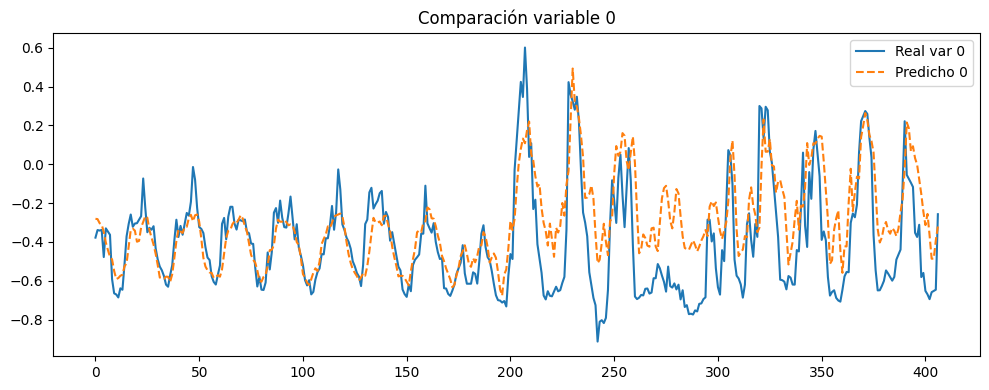

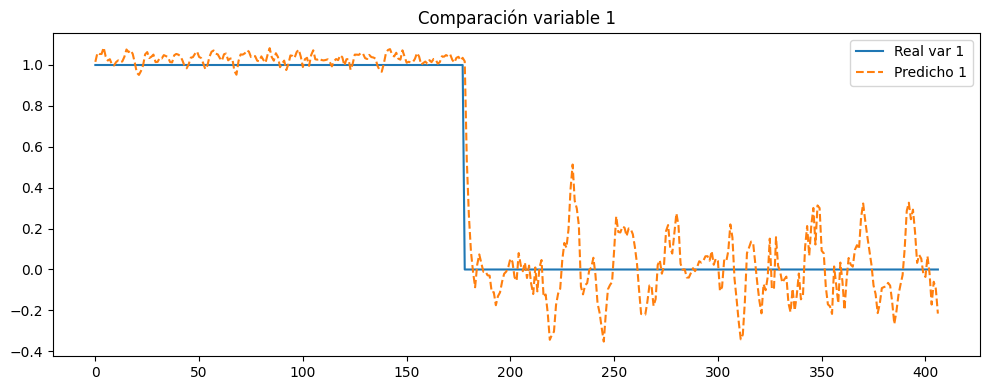

In [31]:
# Evaluación (adaptada al wrapper MultiSeriesSamplerEnv)
obs, _ = env.reset()
preds = []
rewards = []

done = False
while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, _, _ = env.step(action)
    preds.append(action)
    rewards.append(reward)

preds = np.array(preds)
true_vals = env.data[env.window:env.window + len(preds)]

# Determinar número de variables a plotear a partir de la matriz de verdad
n_features = true_vals.shape[1]

import matplotlib.pyplot as plt

for i in range(n_features):
    plt.figure(figsize=(10,4))
    plt.plot(true_vals[:, i], label=f"Real var {i}")
    plt.plot(preds[:, i], '--', label=f"Predicho {i}")
    plt.legend()
    plt.title(f"Comparación variable {i}")
    plt.tight_layout()
    plt.show()

### Evaluacion con Test

In [ ]:
ntoShow = 5

for test_input in test_list:
    # test_input = [ndvi_array, class_array]
    test_env = NDVIMultiEnv(test_input, window=23)
    obs, _ = test_env.reset()
    preds = []
    rewards = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = test_env.step(action)
        preds.append(action)
        rewards.append(reward)
    preds = np.array(preds)
    true_vals = test_env.data[test_env.window:test_env.window + len(preds)]
    
    # Graficar NDVI y clase
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    ax1.plot(true_vals[:, 0], label="Real NDVI", color='blue')
    ax1.plot(preds[:, 0], '--', label="Predicted NDVI", color='red')
    ax1.set_title("NDVI Comparison")
    ax1.legend()
    ax1.set_ylabel("Normalized NDVI")
    
    ax2.plot(true_vals[:, 1], label="Real Class", color='green')
    ax2.plot(preds[:, 1], '--', label="Predicted Class", color='orange')
    ax2.set_title("Class Prediction")
    ax2.legend()
    ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
    ax2.set_xlabel("Timestep")
    ax2.set_ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.show()

TypeError: 'numpy.int64' object is not iterable

### Evaluaciones raras confundiendo,
#### Es particular, le digo que sigue en estado bosque a ver que hace

In [ ]:
# Crear input3: todos 1 (misma longitud que las series NDVI)
input3 = np.ones(len(train_list[0][0]), dtype=np.float32)  # todos 1

In [ ]:
for idx, k in enumerate(test_list):
    # test_input = [ndvi_array, class_array]  (k[0], k[1])
    test_input = [k[0], input3]  # usar input3 (todos 1) sobre la serie de test
    test_env = NDVIMultiEnv(test_input, window=23)
    obs, _ = test_env.reset()
    preds = []
    rewards = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = test_env.step(action)
        preds.append(action)
        rewards.append(reward)
    preds = np.array(preds)
    true_vals = test_env.data[test_env.window:test_env.window + len(preds)]
    
    # Determinar fecha de deforestación original para este test (si existe)
    arr_k1 = np.atleast_1d(np.asarray(k[1]))
    zeros = np.where(arr_k1 == 0)[0]
    def_date = fechas[zeros[0]] if zeros.size > 0 else None
    time_axis = fechas[23:23+len(preds)]
    
    # Plot NDVI y clase
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    ax1.plot(time_axis, true_vals[:, 0], label="Real NDVI", color='green')
    ax1.plot(time_axis, preds[:, 0], '--', label="Predicted NDVI", color='blue')
    if def_date is not None:
        ax1.axvline(def_date, color='red', linestyle='--', label='Deforestación')
    ax1.set_title(f"NDVI Comparison (test {idx})")
    ax1.legend()
    ax1.set_ylabel("Normalized NDVI")
    
    ax2.plot(time_axis, true_vals[:, 1], label="Real Class", color='green')
    ax2.plot(time_axis, preds[:, 1], '--', label="Predicted Class", color='orange')
    if def_date is not None:
        ax2.axvline(def_date, color='red', linestyle='--', label='Deforestación')
    ax2.set_title("Class Prediction")
    ax2.legend()
    ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
    ax2.set_xlabel("Date")
    ax2.set_ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.show()

In [ ]:
# Crear input4: todos 0 (misma longitud que las series NDVI)
input4 = np.zeros(len(train_list[0][0]), dtype=np.float32)  # todos 0

In [ ]:
for idx, k in enumerate(test_list):
    test_input = [k[0], input4]  # usar input4 (todos 0) sobre la serie de test
    test_env = NDVIMultiEnv(test_input, window=23)
    obs, _ = test_env.reset()
    preds = []
    rewards = []
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, _, _ = test_env.step(action)
        preds.append(action)
        rewards.append(reward)
    preds = np.array(preds)
    true_vals = test_env.data[test_env.window:test_env.window + len(preds)]
    
    arr_k1 = np.atleast_1d(np.asarray(k[1]))
    zeros = np.where(arr_k1 == 0)[0]
    def_date = fechas[zeros[0]] if zeros.size > 0 else None
    time_axis = fechas[23:23+len(preds)]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))
    ax1.plot(time_axis, true_vals[:, 0], label="Real NDVI", color='blue')
    ax1.plot(time_axis, preds[:, 0], '--', label="Predicted NDVI", color='red')
    if def_date is not None:
        ax1.axvline(def_date, color='red', linestyle='--', label='Deforestación')
    ax1.set_title(f"NDVI Comparison (test {idx})")
    ax1.legend()
    ax1.set_ylabel("Normalized NDVI")
    
    ax2.plot(time_axis, true_vals[:, 1], label="Real Class", color='green')
    ax2.plot(time_axis, preds[:, 1], '--', label="Predicted Class", color='orange')
    if def_date is not None:
        ax2.axvline(def_date, color='red', linestyle='--', label='Deforestación')
    ax2.set_title("Class Prediction")
    ax2.legend()
    ax2.set_ylabel("Class (0: Forest, 1: Non-forest)")
    ax2.set_xlabel("Date")
    ax2.set_ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.show()